# Two-dimensional capacity-limited redox-front benchmark

## tl;dr

This reader-facing notebook visualizes the validated products from `run.py`.
The benchmark is deliberately coarse and must satisfy one predeclared result:
**SIA < Strang < SNIA error**, with the computational-work order reversed.
The reference is a time-refined numerical solution, not an analytical truth.

In [2]:
import os
import sys
from pathlib import Path

sys.dont_write_bytecode = True
_name = "Splitting_RedoxFront2D"
_candidates = [
    p for base in (Path.cwd(), *Path.cwd().parents) for p in (base, base / "examples" / _name)
]
CASE_DIR = next(
    (p.resolve() for p in _candidates if p.name == _name and (p / "modflow_model.py").is_file()),
    None,
)
if CASE_DIR is None:
    raise FileNotFoundError(f"Cannot locate examples/{_name} from {Path.cwd()}")
os.chdir(CASE_DIR)
sys.path.insert(0, str(CASE_DIR))
__file__ = str(CASE_DIR / "plot.ipynb")
OUTPUT_DIR = CASE_DIR / "output"
SIMULATION_DIR = CASE_DIR / "simulation"

# Saved numerical outputs are distributed losslessly; solver logs are omitted.
import zipfile

for _kind in ("output", "simulation"):
    _base = CASE_DIR / _kind
    for _archive in sorted(_base.glob("saved_results*.zip")):
        with zipfile.ZipFile(_archive) as _zip:
            for _member in _zip.infolist():
                _target = (_base / _member.filename).resolve()
                if not _target.is_relative_to(_base.resolve()):
                    raise ValueError("Archive member escapes the case directory")
                if not _target.exists():
                    _zip.extract(_member, _base)

## Context & Methods

An eight-day donor pulse enters a heterogeneous aquifer, crosses a diagonal
ferric-oxide lens, and is followed by four days of clean-water flushing.
The matrix and lens contain finite solid oxidant capacities; rapid reduction
creates a sharp capacity-exhaustion front.

### Key Assumptions

- coarse SNIA, Strang, and SIA use one logical step per stress period
  (`8 d` pulse step and `4 d` flush step);
- the reference is Strang at `0.125 d`, checked independently at `0.25 d`;
- the combined NRMSE gives equal cell-level weight to donor concentration
  (scale `1e-3 mol/L`) and oxidant consumption (scale `8e-4 model mol`);
- wall time is machine-dependent; transport-solve count is the deterministic
  implementation-independent cost proxy.

In [3]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import Normalize, TwoSlopeNorm

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 240,
        "font.size": 10.0,
        "axes.titleweight": "bold",
    }
)

candidates = [Path.cwd(), Path.cwd() / "examples" / "Splitting_RedoxFront2D"]
CASE_DIR = next(
    (
        path.resolve()
        for path in candidates
        if (path / "output" / "final_fields_comparison.npz").exists()
    ),
    None,
)
if CASE_DIR is None:
    raise FileNotFoundError("Run examples/Splitting_RedoxFront2D/run.py first.")
OUTPUT_DIR = CASE_DIR / "output"
CASE_DIR

WindowsPath('D:/Archives/code/mf6pqc/examples/Splitting_RedoxFront2D')

## Data

### Load and validate the result bundle

In [4]:
with np.load(OUTPUT_DIR / "final_fields_comparison.npz") as archive:
    fields = {name: archive[name].copy() for name in archive.files}
metrics = pd.read_csv(OUTPUT_DIR / "comparison_metrics.csv")
validation = json.loads((OUTPUT_DIR / "validation.json").read_text(encoding="utf-8"))

labels = ("SNIA", "Strang", "SIA", "Reference")
comparison_methods = ("SNIA", "Strang", "SIA")
components = ("Don", "Extent")
required = {
    *(f"{label}_{component}" for label in labels for component in components),
    "hydraulic_conductivity_m_per_day",
    "reactive_lens_mask",
    "solid_oxidant_capacity_model_mol",
    "kinetic_rate_per_day",
    "x_cell_centers_m",
    "y_cell_centers_m",
    "domain_extent_m",
}
missing = sorted(required - fields.keys())
if missing:
    raise RuntimeError(f"Incomplete field archive; missing: {missing}")
if metrics.empty or not np.isfinite(metrics["combined_nrmse"]).all():
    raise RuntimeError("Metrics are empty or contain non-finite errors.")

coarse = metrics.set_index("label").loc[list(comparison_methods)].copy()
error_order = tuple(coarse["combined_nrmse"].sort_values().index)
work_order = tuple(coarse["transport_solves"].sort_values(ascending=False).index)
assert error_order == ("SIA", "Strang", "SNIA")
assert work_order == ("SIA", "Strang", "SNIA")
assert validation["sia_all_steps_converged"]
assert validation["reference_check_combined_nrmse"] < 0.005
assert validation["cross_method_reference_nrmse"] < 0.005

capacity = fields["solid_oxidant_capacity_model_mol"]
for label in labels:
    assert np.all(np.isfinite(fields[f"{label}_Don"]))
    assert np.all(np.isfinite(fields[f"{label}_Extent"]))
    assert np.min(fields[f"{label}_Don"]) >= -2e-10
    assert np.max(fields[f"{label}_Don"]) <= 1.003e-3
    assert np.min(fields[f"{label}_Extent"]) >= -2e-10
    assert np.all(fields[f"{label}_Extent"] <= capacity + 5e-8)

summary_columns = [
    "combined_nrmse",
    "Don_nrmse",
    "Extent_nrmse",
    "transport_solves",
    "reaction_evaluations",
    "wall_time_seconds",
    "oxidant_capacity_utilization_fraction",
    "donor_centroid_x_m",
]
display(coarse[summary_columns])
print("Verified error order:", " < ".join(error_order))
print("Verified work order:", " > ".join(work_order))
print("Reference check NRMSE:", f"{validation['reference_check_combined_nrmse']:.6f}")
print("Cross-method reference NRMSE:", f"{validation['cross_method_reference_nrmse']:.6f}")
print("SIA iterations by logical step:", validation["sia_step_iterations"])

,combined_nrmse,Don_nrmse,Extent_nrmse,transport_solves,reaction_evaluations,wall_time_seconds,oxidant_capacity_utilization_fraction,donor_centroid_x_m
label,,,,,,,,
SNIA,0.059472,0.070053,0.046546,2,2,1.347425,0.091478,0.690792
Strang,0.042859,0.044687,0.040948,4,2,1.340885,0.081195,1.167678
SIA,0.036370,0.031956,0.040304,104,104,88.831797,0.121757,0.945383


Verified error order: SIA < Strang < SNIA
Verified work order: SIA > Strang > SNIA
Reference check NRMSE: 0.001495
Cross-method reference NRMSE: 0.001739
SIA iterations by logical step: [60, 44]


## Results

### Hydrogeological setting and finite oxidant capacity

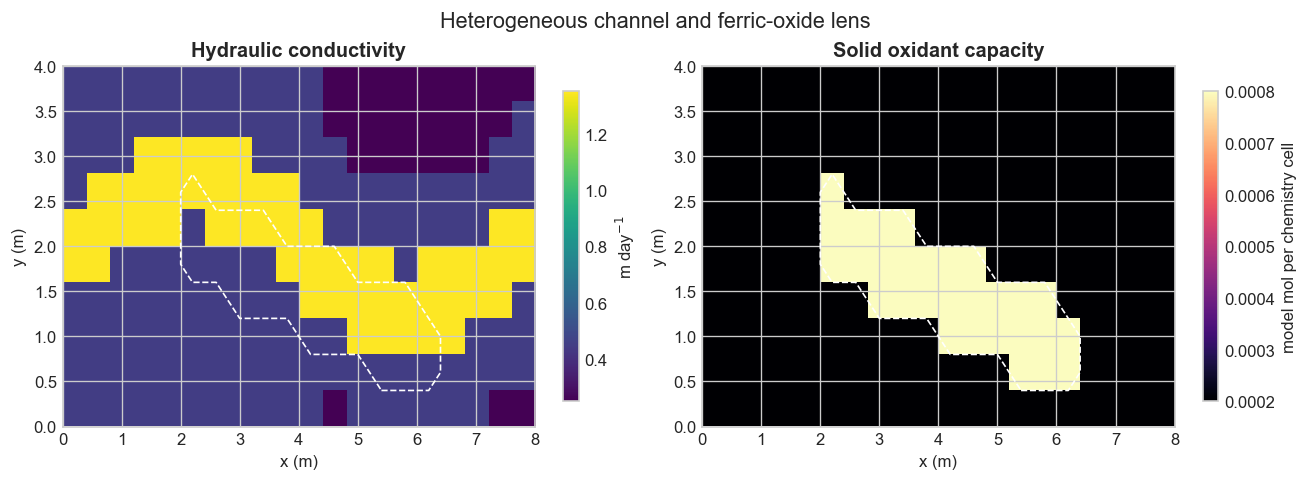

In [5]:
domain_extent = tuple(fields["domain_extent_m"])
lens = fields["reactive_lens_mask"].astype(bool)
x = fields["x_cell_centers_m"]
y = fields["y_cell_centers_m"]

figure, axes = plt.subplots(1, 2, figsize=(10.8, 3.9), constrained_layout=True)
context_specs = (
    ("hydraulic_conductivity_m_per_day", "viridis", "Hydraulic conductivity", "m day$^{-1}$"),
    (
        "solid_oxidant_capacity_model_mol",
        "magma",
        "Solid oxidant capacity",
        "model mol per chemistry cell",
    ),
)
for axis, (key, cmap, title, unit) in zip(axes, context_specs, strict=False):
    image = axis.imshow(fields[key], origin="lower", extent=domain_extent, aspect="auto", cmap=cmap)
    axis.contour(
        x, y, lens.astype(float), levels=[0.5], colors="white", linewidths=1.0, linestyles="--"
    )
    axis.set(title=title, xlabel="x (m)", ylabel="y (m)")
    figure.colorbar(image, ax=axis, shrink=0.86, label=unit)
figure.suptitle("Heterogeneous channel and ferric-oxide lens", fontsize=13)
figure.savefig(OUTPUT_DIR / "case_context.png", bbox_inches="tight")
plt.show()

### Final donor plume and oxidant-capacity utilization

Every row uses one common color scale. The dashed contour marks the
high-capacity lens; the bottom row is local consumed capacity divided by local
initial capacity.

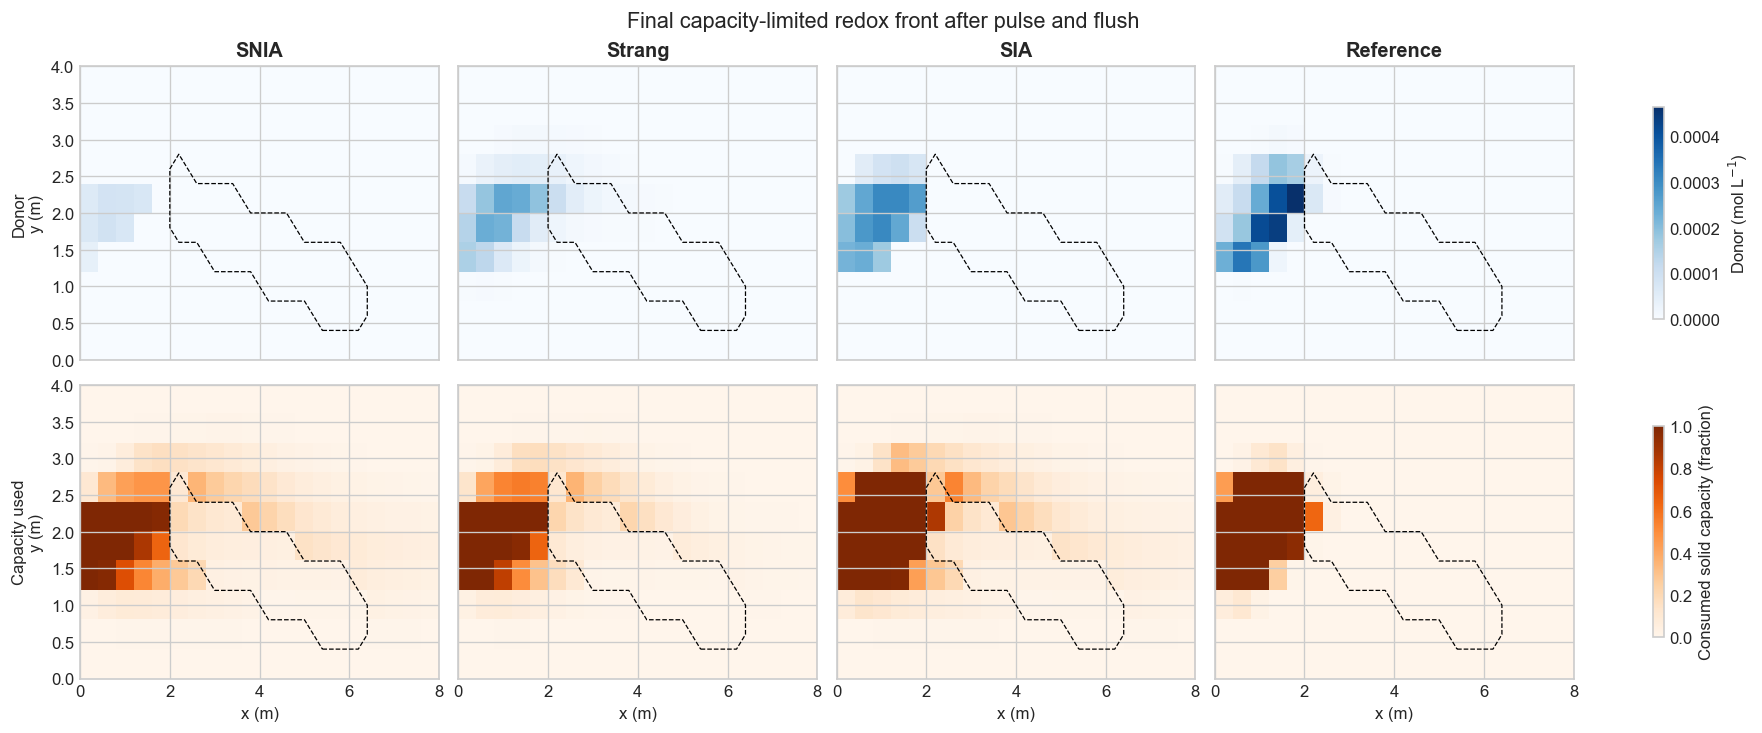

In [6]:
donor_max = max(float(np.max(fields[f"{label}_Don"])) for label in labels)
row_specs = (
    ("Don", Normalize(0.0, max(donor_max, 1e-12)), "Blues", "Donor (mol L$^{-1}$)"),
    ("Extent", Normalize(0.0, 1.0), "Oranges", "Consumed solid capacity (fraction)"),
)
figure, axes = plt.subplots(
    2, 4, figsize=(14.6, 6.0), sharex=True, sharey=True, constrained_layout=True
)
mappables = []
for column, label in enumerate(labels):
    for row, (component, norm, cmap, colorbar_label) in enumerate(row_specs):
        values = fields[f"{label}_{component}"]
        if component == "Extent":
            values = values / capacity
        axis = axes[row, column]
        image = axis.imshow(
            values, origin="lower", extent=domain_extent, aspect="auto", cmap=cmap, norm=norm
        )
        axis.contour(
            x, y, lens.astype(float), levels=[0.5], colors="black", linewidths=0.75, linestyles="--"
        )
        if row == 0:
            axis.set_title(label)
        if column == 0:
            axis.set_ylabel(("Donor" if row == 0 else "Capacity used") + "\ny (m)")
        if row == 1:
            axis.set_xlabel("x (m)")
        if column == 0:
            mappables.append((image, colorbar_label))
for row, (image, colorbar_label) in enumerate(mappables):
    figure.colorbar(image, ax=list(axes[row, :]), shrink=0.72, label=colorbar_label)
figure.suptitle("Final capacity-limited redox front after pulse and flush", fontsize=13)
figure.savefig(OUTPUT_DIR / "final_fields_comparison.png", bbox_inches="tight")
plt.show()

### Signed errors relative to the refined numerical reference

Red indicates overprediction and blue underprediction. The donor and solid
state retain separate physical units and separate symmetric color scales.

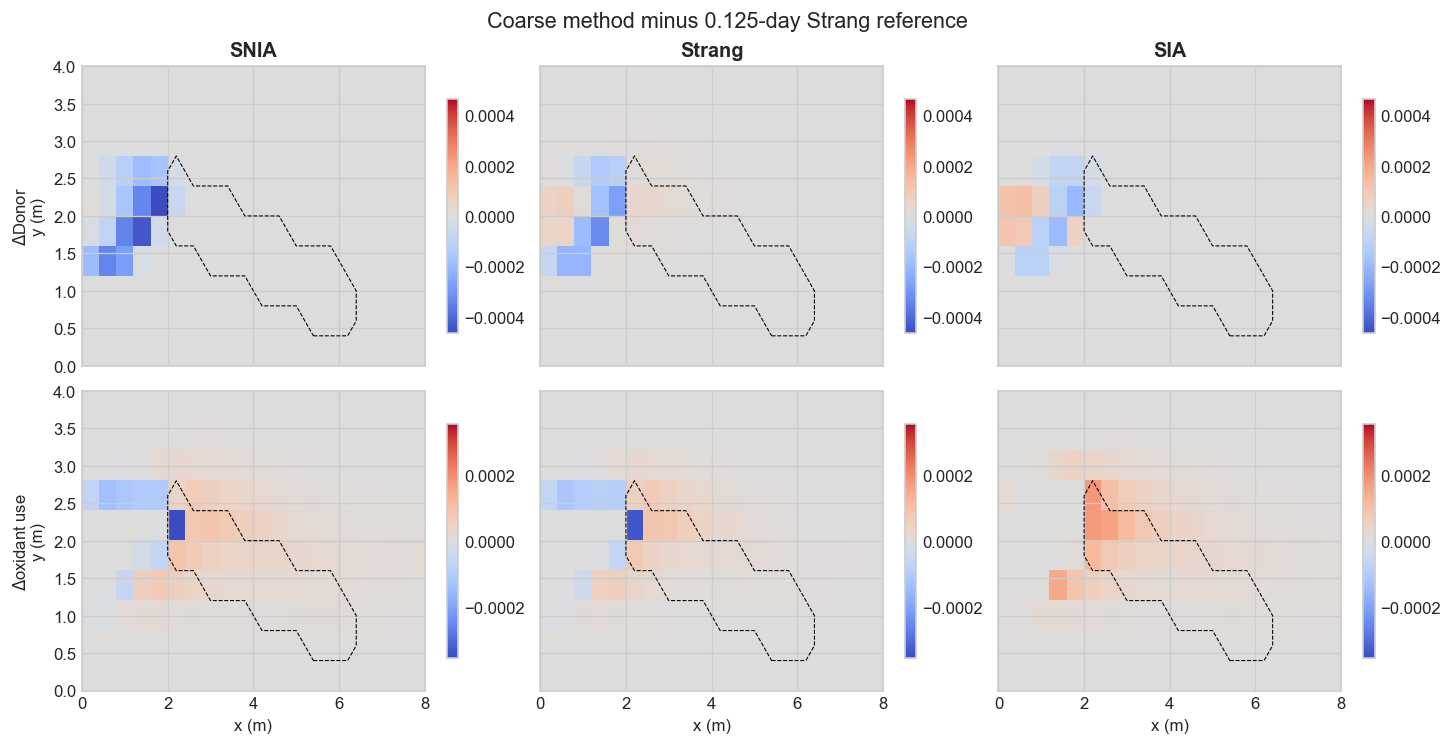

In [7]:
differences = {
    (method, component): (fields[f"{method}_{component}"] - fields[f"Reference_{component}"])
    for method in comparison_methods
    for component in components
}
limits = {
    component: max(
        float(np.max(np.abs(differences[(method, component)]))) for method in comparison_methods
    )
    for component in components
}
figure, axes = plt.subplots(
    2, 3, figsize=(12.0, 6.1), sharex=True, sharey=True, constrained_layout=True
)
for column, method in enumerate(comparison_methods):
    for row, component in enumerate(components):
        limit = max(limits[component], 1e-15)
        image = axes[row, column].imshow(
            differences[(method, component)],
            origin="lower",
            extent=domain_extent,
            aspect="auto",
            cmap="coolwarm",
            norm=TwoSlopeNorm(vmin=-limit, vcenter=0.0, vmax=limit),
        )
        axes[row, column].contour(
            x, y, lens.astype(float), levels=[0.5], colors="black", linewidths=0.65, linestyles="--"
        )
        if row == 0:
            axes[row, column].set_title(method)
        if column == 0:
            axes[row, column].set_ylabel(
                (r"$\Delta$Donor" if row == 0 else r"$\Delta$oxidant use") + "\ny (m)"
            )
        if row == 1:
            axes[row, column].set_xlabel("x (m)")
        figure.colorbar(image, ax=axes[row, column], shrink=0.78)
figure.suptitle("Coarse method minus 0.125-day Strang reference", fontsize=13)
figure.savefig(OUTPUT_DIR / "error_fields_comparison.png", bbox_inches="tight")
plt.show()

### Accuracy–cost hierarchy

The left panel is the predeclared combined error. The middle panel shows
observed runtime; the right panel uses deterministic transport solves.

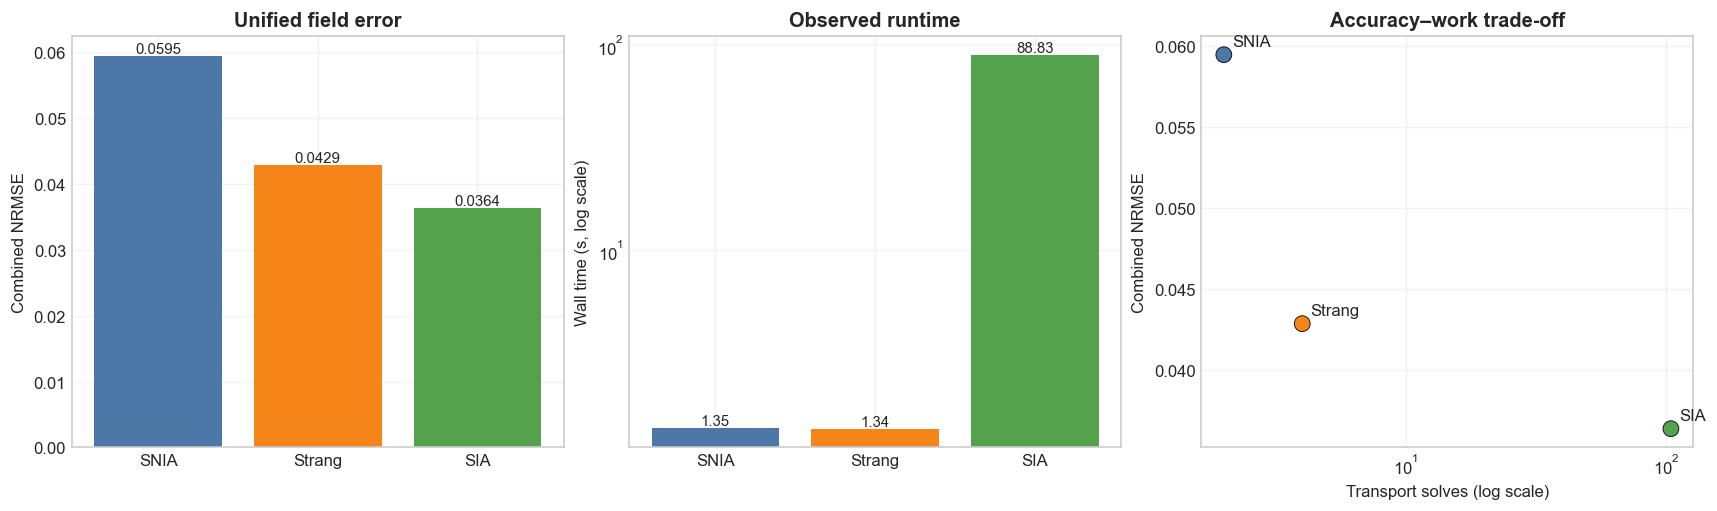

,combined_nrmse,Don_nrmse,Extent_nrmse,transport_solves,reaction_evaluations,total_sia_iterations,wall_time_seconds,oxidant_capacity_utilization_fraction,ninety_percent_depleted_area_m2
label,,,,,,,,,
SNIA,0.059472,0.070053,0.046546,2,2,NaN,1.347425,0.091478,1.60
Strang,0.042859,0.044687,0.040948,4,2,NaN,1.340885,0.081195,1.76
SIA,0.036370,0.031956,0.040304,104,104,104.0,88.831797,0.121757,2.88


In [8]:
colors = ["#4c78a8", "#f58518", "#54a24b"]
figure, axes = plt.subplots(1, 3, figsize=(14.2, 4.15), constrained_layout=True)

axes[0].bar(coarse.index, coarse["combined_nrmse"], color=colors)
axes[0].set(title="Unified field error", ylabel="Combined NRMSE")
for index, value in enumerate(coarse["combined_nrmse"]):
    axes[0].text(index, value, f"{value:.4f}", ha="center", va="bottom", fontsize=9)

axes[1].bar(coarse.index, coarse["wall_time_seconds"], color=colors)
axes[1].set_yscale("log")
axes[1].set(title="Observed runtime", ylabel="Wall time (s, log scale)")
for index, value in enumerate(coarse["wall_time_seconds"]):
    axes[1].text(index, value, f"{value:.2f}", ha="center", va="bottom", fontsize=9)

axes[2].scatter(
    coarse["transport_solves"],
    coarse["combined_nrmse"],
    s=90,
    c=colors,
    edgecolor="black",
    linewidth=0.5,
)
for label, row in coarse.iterrows():
    axes[2].annotate(
        label,
        (row["transport_solves"], row["combined_nrmse"]),
        xytext=(5, 5),
        textcoords="offset points",
    )
axes[2].set_xscale("log")
axes[2].set(
    xlabel="Transport solves (log scale)", ylabel="Combined NRMSE", title="Accuracy–work trade-off"
)
for axis in axes:
    axis.grid(True, alpha=0.25)
figure.savefig(OUTPUT_DIR / "error_cost_comparison.png", bbox_inches="tight")
plt.show()

display(
    coarse[
        [
            "combined_nrmse",
            "Don_nrmse",
            "Extent_nrmse",
            "transport_solves",
            "reaction_evaluations",
            "total_sia_iterations",
            "wall_time_seconds",
            "oxidant_capacity_utilization_fraction",
            "ninety_percent_depleted_area_m2",
        ]
    ]
)

## Takeaways

- The executed regression gate requires the unified error order
  `SIA < Strang < SNIA`; failure stops `run.py` and this notebook.
- Computational work is deliberately reversed: SIA iterates the capacity
  sink to closure, Strang performs two transport half-steps, and SNIA performs
  one transport step per period.
- The result is a **strong-splitting benchmark**, not a universal ranking.
  The `0.125 d` Strang field is a converged numerical reference on this fixed
  spatial grid, not an analytical or globally implicit exact solution. A
  same-step `0.125 d` SNIA result provides an independent cross-method check.
- Wall time should be reported with machine context; transport and reaction
  evaluation counts are the portable cost evidence.